In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Import datasets
data1 = pd.read_csv('data1.csv')
data2 = pd.read_csv('data2.csv')

In [3]:
data1[data1["Background"] == "Lettres"]

,UserName,Age,Background
43,Name44,22,Lettres
45,Name46,20,Lettres
48,Name49,23,Lettres
50,Name51,36,Lettres


In [4]:
x =pd.get_dummies(data1,columns=["Background"])
print(x)

   UserName  Age  Background_Economie et gestion  Background_Lettres  \
0     Name1   20                            True               False   
1     Name2   21                            True               False   
2     Name3   19                            True               False   
3     Name4   24                            True               False   
4     Name5   30                           False               False   
5     Name6   22                           False               False   
6     Name7   23                           False               False   
7     Name8   21                            True               False   
8     Name9   20                           False               False   
9    Name10   24                            True               False   
10   Name11   27                            True               False   
11   Name12   19                            True               False   
12   Name13   25                            True               F

In [5]:
f1 = x["Age"].values
f2 = x["Background_Economie et gestion"].values
f3 = x["Background_Lettres"].values
f4 = x["Background_Sciences et technologies"].values
x = np.array(list(zip(f1,f2,f3,f4)))

In [6]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(x)
x=scaler.transform(x)
x

array([[0.2 , 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.15, 1.  , 0.  , 0.  ],
       [0.4 , 1.  , 0.  , 0.  ],
       [0.7 , 0.  , 0.  , 1.  ],
       [0.3 , 0.  , 0.  , 1.  ],
       [0.35, 0.  , 0.  , 1.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.2 , 0.  , 0.  , 1.  ],
       [0.4 , 1.  , 0.  , 0.  ],
       [0.55, 1.  , 0.  , 0.  ],
       [0.15, 1.  , 0.  , 0.  ],
       [0.45, 1.  , 0.  , 0.  ],
       [0.35, 0.  , 0.  , 1.  ],
       [0.25, 0.  , 0.  , 1.  ],
       [0.15, 0.  , 0.  , 1.  ],
       [0.4 , 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.55, 0.  , 0.  , 1.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.05, 1.  , 0.  , 0.  ],
       [0.9 , 0.  , 0.  , 1.  ],
       [0.15, 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.3 , 0.  , 0.  , 1.  ],
       [0.95, 0.  , 0.  , 1.  ],
       [0.25, 0.  , 0.  , 1.  ],
       [0.75, 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  ],
       [0.45, 0.  , 0.  , 1.  ],
       [0.

Text(0, 0.5, 'Inertie')

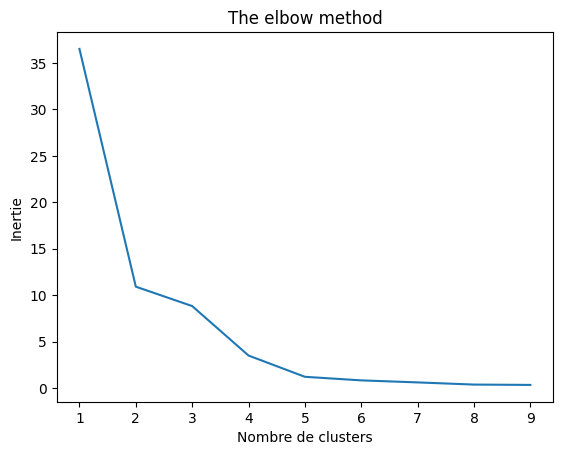

In [7]:
from sklearn.cluster import KMeans
inertia = []
for i in range (1,10):
    kmeans = KMeans(i)
    kmeans.fit(x)
    inertia_iter = kmeans.inertia_
    inertia.append(inertia_iter)

number_clusters=range(1,10)
plt.plot(number_clusters,inertia)
plt.title("The elbow method")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")

In [8]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3)
kmeans.fit(x)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [9]:
clusters = kmeans.predict(x)
clusters

array([0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 2,
       1, 2, 1, 1, 2, 1, 2, 0, 0, 0, 0, 1, 1, 1], dtype=int32)

In [10]:
frame =  pd.DataFrame(x)
frame["cluster"] = clusters
frame["cluster"].value_counts()

cluster
0    28
1    26
2     4
Name: count, dtype: int64

In [11]:
import plotly.express as px
frame = pd.DataFrame(x, columns=['Age', 'Background_Economie et gestion', 'Background_Lettres', 'Background_Sciences et technologies'])
fig2 = px.scatter_3d(frame,x='Age', y='Background_Economie et gestion', z='Background_Lettres', color=clusters.astype(str))
fig2.update_layout(title='3D Scatter Plot of Clusters', scene=dict(xaxis_title='Age', yaxis_title='Bg_Eco et gest', zaxis_title='Bg_Lettres'))
fig2.show()

In [42]:
y =pd.get_dummies(data2,columns=["Background", "Genre"])
print(y)

   UserName  Age  MembreAssociation  Background_Economie et gestion  \
0     Name1   20                  1                            True   
1     Name2   21                  0                            True   
2     Name3   19                  0                            True   
3     Name4   24                  0                            True   
4     Name5   30                  0                           False   
5     Name6   22                  0                           False   
6     Name7   23                  1                           False   
7     Name8   21                  0                            True   
8     Name9   20                  0                           False   
9    Name10   24                  1                            True   
10   Name11   27                  1                            True   
11   Name12   19                  1                            True   
12   Name13   25                  1                            True   
13   N

In [43]:
y

,UserName,Age,MembreAssociation,Background_Economie et gestion,Background_Lettres,Background_Sciences et technologies,Genre_F,Genre_M
0,Name1,20,1,True,False,False,True,False
1,Name2,21,0,True,False,False,False,True
2,Name3,19,0,True,False,False,False,True
3,Name4,24,0,True,False,False,False,True
4,Name5,30,0,False,False,True,True,False
5,Name6,22,0,False,False,True,True,False
6,Name7,23,1,False,False,True,True,False
7,Name8,21,0,True,False,False,False,True
8,Name9,20,0,False,False,True,False,True
9,Name10,24,1,True,False,False,False,True


In [45]:
f1 = y["Age"].values
f2 = y["Background_Economie et gestion"].values
f3 = y["Background_Lettres"].values
f4 = y["Background_Sciences et technologies"].values
f5 = y["Genre_M"].values
f6 = y["Genre_F"].values
f6 = y["MembreAssociation"].values

y = np.array(list(zip(f1,f2,f3,f4,f5,f6)))


In [46]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaler.fit(y)
y=scaler.transform(y)
y

array([[0.2 , 1.  , 0.  , 0.  , 0.  , 1.  ],
       [0.25, 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.15, 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.4 , 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.7 , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.3 , 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.35, 0.  , 0.  , 1.  , 0.  , 1.  ],
       [0.25, 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.2 , 0.  , 0.  , 1.  , 1.  , 0.  ],
       [0.4 , 1.  , 0.  , 0.  , 1.  , 1.  ],
       [0.55, 1.  , 0.  , 0.  , 0.  , 1.  ],
       [0.15, 1.  , 0.  , 0.  , 1.  , 1.  ],
       [0.45, 1.  , 0.  , 0.  , 0.  , 1.  ],
       [0.35, 0.  , 0.  , 1.  , 1.  , 1.  ],
       [0.25, 0.  , 0.  , 1.  , 1.  , 0.  ],
       [0.15, 0.  , 0.  , 1.  , 1.  , 0.  ],
       [0.4 , 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  , 1.  , 1.  ],
       [0.55, 0.  , 0.  , 1.  , 0.  , 0.  ],
       [0.25, 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.05, 1.  , 0.  , 0.  , 1.  , 0.  ],
       [0.9 , 0.  , 0.  , 1.  , 1.  , 1.  ],
       [0.

In [47]:
from sklearn.cluster import KMeans
inertia = []
for i in range (1,10):
    kmeans = KMeans(i)
    kmeans.fit(y)
    inertia_iter = kmeans.inertia_
    inertia.append(inertia_iter)

Text(0, 0.5, 'Inertie')

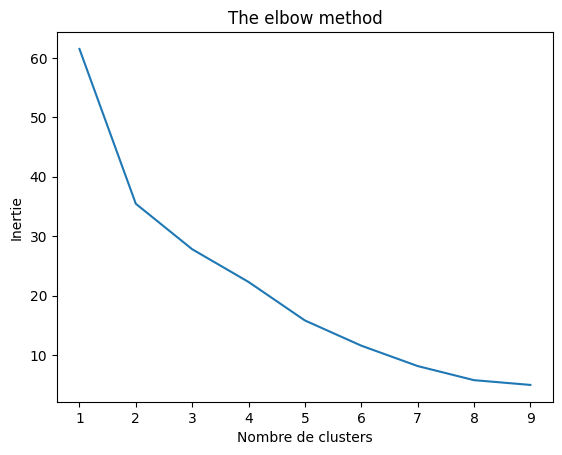

In [48]:
number_clusters=range(1,10)
plt.plot(number_clusters,inertia)
plt.title("The elbow method")
plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")

In [49]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3)
kmeans.fit(y)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [50]:
clusters = kmeans.predict(y)
clusters

array([1, 1, 1, 1, 2, 2, 0, 1, 2, 1, 0, 1, 0, 0, 2, 2, 1, 1, 2, 1, 1, 0,
       1, 1, 0, 2, 2, 1, 1, 2, 0, 1, 2, 1, 2, 2, 2, 0, 1, 1, 1, 2, 1, 2,
       2, 0, 2, 2, 2, 2, 2, 1, 1, 1, 1, 0, 2, 2], dtype=int32)

In [51]:
frame =  pd.DataFrame(y)
frame["cluster"] = clusters
frame["cluster"].value_counts()

cluster
1    25
2    23
0    10
Name: count, dtype: int64

In [53]:
import plotly.express as px
frame = pd.DataFrame(y, columns=['Age', 'Background_Economie et gestion', 'Background_Lettres', 'Background_Sciences et technologies',"Genre_M","Genre_F"])
fig2 = px.scatter_3d(frame,x='Age', y='Background_Economie et gestion', z='Background_Lettres', color=clusters.astype(str))
fig2.update_layout(title='3D Scatter Plot of Clusters', scene=dict(xaxis_title='Age', yaxis_title='Bg_Eco et gest', zaxis_title='Bg_Lettres'))
fig2.show()